<a href="https://colab.research.google.com/github/siyadalvi0331/CSL701-CE06_Machine-Learning-Lab/blob/main/ML_EXP2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
Name:Siya Vishram Dalvi
Roll No:CE06

In [ ]:
Experiment No 2


In [ ]:
Aim: To implement a Simple Linear Regression model using Python and predict MPG from Horsepower using OLS.

In [39]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [40]:
# Import required libraries
from google.colab import files

uploaded = files.upload()


Saving auto-mpg.csv to auto-mpg (1).csv


In [41]:
# Inspect and clean the dataset

print("\nDataset Information:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nUnique values in horsepower:")
print(df["horsepower"].unique())
# Convert horsepower to numeric
# Invalid values such as '?' will become NaN

df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")

# Remove rows containing missing values
df = df.dropna(subset=["horsepower", "mpg"])

print("\nShape after cleaning:", df.shape)

print("\nMissing values after cleaning:")
print(df[["horsepower", "mpg"]].isnull().sum())



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model_year    392 non-null    int64  
 7   origin        392 non-null    object 
 8   name          392 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 30.6+ KB
None

Missing values:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

Unique values in horsepower:
[130. 165. 150. 140. 198. 220. 215. 225. 190. 170. 160.  95.  97.  85.
  88.  46.  87.  90. 113. 200. 210. 193. 100.

In [42]:
# Select horsepower and mpg

X = df["horsepower"].values
y = df["mpg"].values

print("\nNumber of observations:", len(X))
print("Horsepower range:", X.min(), "to", X.max())
print("MPG range:", y.min(), "to", y.max())



Number of observations: 392
Horsepower range: 46.0 to 230.0
MPG range: 9.0 to 46.6


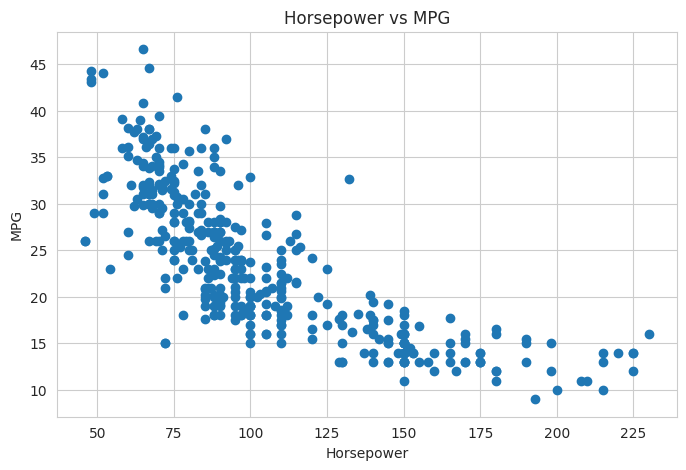

In [43]:
# Plot scatter graph

plt.figure(figsize=(8, 5))

plt.scatter(X, y)

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Horsepower vs MPG")

plt.grid(True)
plt.show()

In [44]:
# Add bias (intercept) term

# Add a column of ones for the intercept

X_matrix = np.column_stack((np.ones(len(X)), X))

print("\nFirst 5 rows of X matrix:")
print(X_matrix[:5])

print("\nShape of X matrix:", X_matrix.shape)


First 5 rows of X matrix:
[[  1. 130.]
 [  1. 165.]
 [  1. 150.]
 [  1. 150.]
 [  1. 140.]]

Shape of X matrix: (392, 2)


In [45]:
# Compute correlation between horsepower and MPG

correlation = np.corrcoef(X, y)[0, 1]

print("\nCorrelation between Horsepower and MPG:")
print(correlation)


Correlation between Horsepower and MPG:
-0.7784267838977756


In [46]:
# Calculate OLS weights

# Normal equation:
# w = (X^T X)^(-1) X^T y

XTX = X_matrix.T @ X_matrix
XTy = X_matrix.T @ y

print("\nX^T X:")
print(XTX)

print("\nX^T y:")
print(XTy)

# Check determinant
determinant = np.linalg.det(XTX)

print("\nDeterminant of X^T X:")
print(determinant)

if determinant != 0:

    # Calculate OLS weights
    w = np.linalg.inv(XTX) @ XTy

else:
    print("X^T X is singular. Cannot calculate inverse.")
    raise ValueError("X^T X is singular.")


intercept = w[0]
slope = w[1]

print("\nOLS Weights:")
print("Intercept (w0):", intercept)
print("Slope (w1):", slope)

print("\nRegression Equation:")
print(f"MPG = {intercept:.4f} + ({slope:.4f}) × Horsepower")


X^T X:
[[3.920000e+02 4.095200e+04]
 [4.095200e+04 4.857524e+06]]

X^T y:
[  9190.8 868718.8]

Determinant of X^T X:
227083104.0000001

OLS Weights:
Intercept (w0): 39.93586102117056
Slope (w1): -0.1578447333536543

Regression Equation:
MPG = 39.9359 + (-0.1578) × Horsepower


In [47]:
# Predict MPG values

y_pred = X_matrix @ w

print("\nFirst 10 actual MPG values:")
print(y[:10])

print("\nFirst 10 predicted MPG values:")
print(y_pred[:10])


First 10 actual MPG values:
[18. 15. 18. 16. 17. 15. 14. 14. 14. 15.]

First 10 predicted MPG values:
[19.41604569 13.89148002 16.25915102 16.25915102 17.83759835  8.68260382
  5.21001968  5.99924335  4.42079602  9.94536168]


In [48]:
# Compute residuals

residuals = y - y_pred

print("\nFirst 10 residuals:")
print(residuals[:10])



First 10 residuals:
[-1.41604569  1.10851998  1.74084898 -0.25915102 -0.83759835  6.31739618
  8.78998032  8.00075665  9.57920398  5.05463832]


In [49]:
#Calculate SSE, MSE, R²
# Sum of Squared Errors
SSE = np.sum(residuals ** 2)

# Mean Squared Error
MSE = SSE / len(y)

# Total Sum of Squares
SST = np.sum((y - np.mean(y)) ** 2)

# R-squared
R2 = 1 - (SSE / SST)

print("\nEvaluation Metrics:")
print("SSE =", SSE)
print("MSE =", MSE)
print("R²  =", R2)


Evaluation Metrics:
SSE = 9385.915871932419
MSE = 23.943662938603108
R²  = 0.6059482578894348


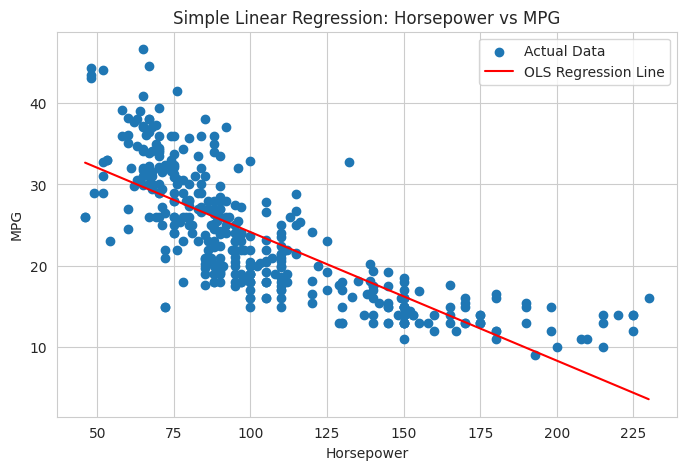

In [50]:
#Plot regression line
plt.figure(figsize=(8, 5))

plt.scatter(X, y, label="Actual Data")

# Sort X for a smooth regression line
sort_index = np.argsort(X)

plt.plot(
    X[sort_index],
    y_pred[sort_index],
    color="red",
    label="OLS Regression Line"
)

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Simple Linear Regression: Horsepower vs MPG")

plt.legend()
plt.grid(True)
plt.show()

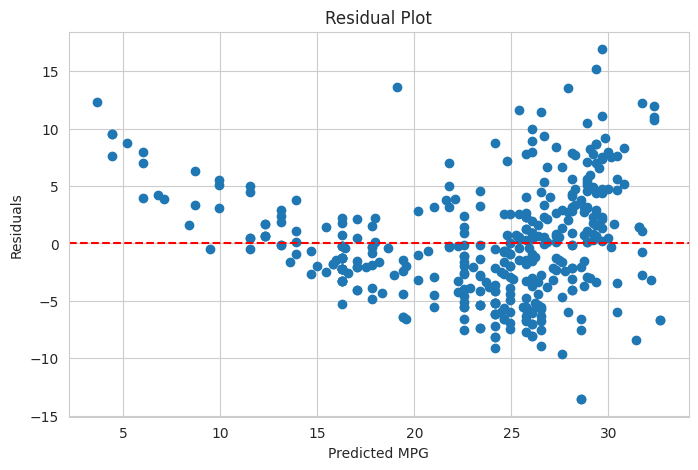

In [51]:
#Residual plot
plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    label="Zero Residual Line"
)

plt.xlabel("Predicted MPG")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.grid(True)
plt.show()

In [52]:
#Interpret results
print("\n========== INTERPRETATION ==========")

print(f"Correlation = {correlation:.4f}")

if slope < 0:
    print("Horsepower has a negative relationship with MPG.")
    print("As horsepower increases, MPG tends to decrease.")
else:
    print("Horsepower has a positive relationship with MPG.")
    print("As horsepower increases, MPG tends to increase.")

print(f"\nFor every 1-unit increase in horsepower,")
print(f"predicted MPG changes by approximately {abs(slope):.4f} MPG.")

print(f"\nR² = {R2:.4f}")

print(f"This means approximately {R2 * 100:.2f}% of the variation")
print("in MPG is explained by horsepower in this simple linear model.")


========== INTERPRETATION ==========
Correlation = -0.7784
Horsepower has a negative relationship with MPG.
As horsepower increases, MPG tends to decrease.

For every 1-unit increase in horsepower,
predicted MPG changes by approximately 0.1578 MPG.

R² = 0.6059
This means approximately 60.59% of the variation
in MPG is explained by horsepower in this simple linear model.
